In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [ ]:
df_sissi = "C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissi_oversampling.xlsx"
df_multiperm_mono = "C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx"

df1 = pd.read_excel(df_sissi, usecols=['z-score calculated from 7. 8. and 9.'])
df2 = pd.read_excel(df_multiperm_mono, usecols=['z-score calculated from 7. 8. and 9.'])

df1["Label"] = 1
df2["Label"] = np.where(df2['z-score calculated from 7. 8. and 9.'] > -4 , 1, 0)

df = pd.concat([df1, df2], ignore_index=True)

df.head()

,z-score calculated from 7. 8. and 9.,Label
0,-17.54,1
1,-33.39,1
2,-28.15,1
3,-21.36,1
4,-21.70,1


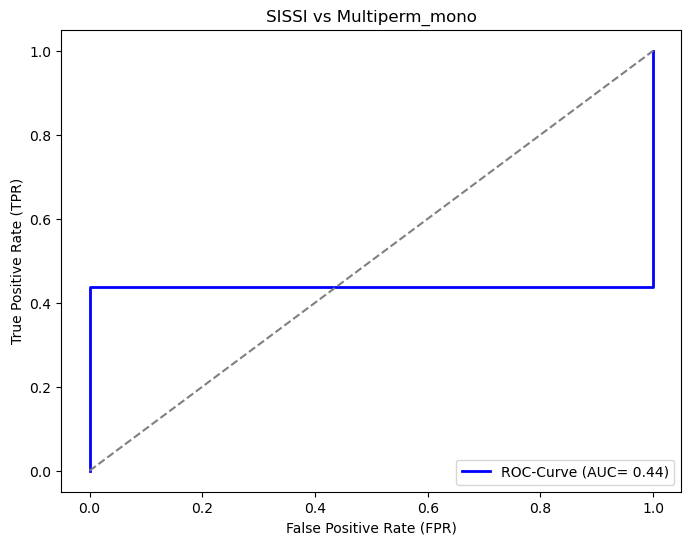

In [31]:
fpr,tpr, _ = roc_curve(df["Label"], df['z-score calculated from 7. 8. and 9.'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC-Curve (AUC= {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("SISSI vs Multiperm_mono")
plt.legend(loc="lower right")
plt.show()